# **1. Perkenalan Dataset**


## Informasi Dataset

Dataset yang digunakan pada eksperimen ini adalah **Wine Quality Dataset (Red Wine)** yang bersumber dari UCI Machine Learning Repository — salah satu repository dataset publik paling terpercaya di dunia.

### Identitas Eksperimen
| Atribut | Detail |
|---------|--------|
| **Nama Siswa** | Sonyalfauzan |
| **Dataset** | Wine Quality — Red Wine (UCI ML Repository) |
| **Sumber** | https://archive.ics.uci.edu/ml/datasets/wine+quality |
| **Tipe Masalah** | Binary Classification |
| **Framework** | Scikit-Learn |

### Deskripsi Dataset

Dataset ini berisi hasil pengujian fisikokimia terhadap sampel wine merah Portugal (Vinho Verde). Setiap sampel memiliki **11 fitur kuantitatif** hasil uji laboratorium dan satu nilai kualitas yang diberikan oleh pakar wine melalui uji sensorik.

| Fitur | Deskripsi | Satuan |
|-------|-----------|--------|
| fixed acidity | Keasaman tetap (asam tartrat) | g/dm³ |
| volatile acidity | Keasaman volatil (asam asetat) | g/dm³ |
| citric acid | Asam sitrat | g/dm³ |
| residual sugar | Gula sisa setelah fermentasi | g/dm³ |
| chlorides | Kandungan natrium klorida | g/dm³ |
| free sulfur dioxide | SO₂ bebas | mg/dm³ |
| total sulfur dioxide | Total SO₂ | mg/dm³ |
| density | Densitas wine | g/cm³ |
| pH | Tingkat keasaman | - |
| sulphates | Kalium sulfat (pengawet) | g/dm³ |
| alcohol | Kadar alkohol | % vol |
| **quality** | **Skor kualitas dari pakar (3–8)** | **-** |

### Business Understanding

Penilaian kualitas wine secara tradisional mengandalkan panelis ahli (sommelier) yang memberikan skor secara sensorik — proses yang mahal, subjektif, dan tidak skalabel untuk produksi massal. Dengan memanfaatkan parameter fisikokimia yang dapat diukur secara objektif di laboratorium, model machine learning dapat mengotomatiskan penilaian kualitas wine secara konsisten.

**Problem Statement:** Apakah sebuah wine termasuk kategori **berkualitas baik (Good, quality ≥ 7)** atau **berkualitas buruk (Bad, quality < 7)** berdasarkan komposisi kimianya?

**Goals:**
- Membangun classifier binary dengan akurasi ≥ 85%
- Mengidentifikasi fitur kimia paling berpengaruh terhadap kualitas wine
- Menyediakan pipeline preprocessing yang dapat direproduksi dan diotomasi

**Solution:** Random Forest Classifier dengan hyperparameter tuning menggunakan RandomizedSearchCV, dilacak menggunakan MLflow dan DagsHub.


# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data, visualisasi, preprocessing, dan pembangunan model machine learning.


In [1]:
# ============================================================
# Import Library
# ============================================================

# Standard library
import os
import warnings
import pickle

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay,
)
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

# Visualization settings
plt.rcParams['figure.figsize']  = (12, 6)
plt.rcParams['font.size']       = 11
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_palette('husl')

print("=" * 50)
print("Library berhasil diimport!")
print("=" * 50)
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")
print(f"  Matplotlib : {plt.matplotlib.__version__}")
print(f"  Seaborn    : {sns.__version__}")

import sklearn
print(f"  Scikit-Learn: {sklearn.__version__}")


Library berhasil diimport!
  NumPy      : 2.0.2
  Pandas     : 2.2.2
  Matplotlib : 3.10.0
  Seaborn    : 0.13.2
  Scikit-Learn: 1.6.1


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset Wine Quality langsung dari URL resmi UCI Machine Learning Repository menggunakan `pandas`. Dataset disimpan juga secara lokal sebagai raw data untuk keperluan version control dan reprodusibilitas.


In [2]:
# ============================================================
# 3.1 Load Dataset dari URL UCI ML Repository
# ============================================================

DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)

print("Memuat dataset dari UCI ML Repository ...")
df = pd.read_csv(DATA_URL, sep=';')

# Simpan raw dataset secara lokal
os.makedirs("winequality_raw", exist_ok=True)
df.to_csv("winequality_raw/winequality-red.csv", index=False)

print(f"Dataset berhasil dimuat dan disimpan!")
print(f"  Shape        : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Ukuran memori: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"  File lokal   : winequality_raw/winequality-red.csv")


Memuat dataset dari UCI ML Repository ...
Dataset berhasil dimuat dan disimpan!
  Shape        : 1,599 baris × 12 kolom
  Ukuran memori: 150.04 KB
  File lokal   : winequality_raw/winequality-red.csv


In [3]:
# ============================================================
# 3.2 Tampilkan Sampel Dataset
# ============================================================

print("5 baris pertama dataset:")
display(df.head())

print(f"\n5 baris terakhir dataset:")
display(df.tail())


5 baris pertama dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



5 baris terakhir dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [4]:
# ============================================================
# 3.3 Informasi Umum Dataset
# ============================================================

print("Informasi Tipe Data:")
print(df.dtypes)
print(f"\nRingkasan Statistik:")
display(df.describe().round(4))


Informasi Tipe Data:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Ringkasan Statistik:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000
mean,8.3196,0.5278,0.2710,2.5388,0.0875,15.8749,46.4678,0.9967,3.3111,0.6581,10.4230,5.6360
std,1.7411,0.1791,0.1948,1.4099,0.0471,10.4602,32.8953,0.0019,0.1544,0.1695,1.0657,0.8076
min,4.6000,0.1200,0.0000,0.9000,0.0120,1.0000,6.0000,0.9901,2.7400,0.3300,8.4000,3.0000
25%,7.1000,0.3900,0.0900,1.9000,0.0700,7.0000,22.0000,0.9956,3.2100,0.5500,9.5000,5.0000
50%,7.9000,0.5200,0.2600,2.2000,0.0790,14.0000,38.0000,0.9968,3.3100,0.6200,10.2000,6.0000
75%,9.2000,0.6400,0.4200,2.6000,0.0900,21.0000,62.0000,0.9978,3.4000,0.7300,11.1000,6.0000
max,15.9000,1.5800,1.0000,15.5000,0.6110,72.0000,289.0000,1.0037,4.0100,2.0000,14.9000,8.0000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan EDA secara menyeluruh untuk memahami karakteristik dataset sebelum masuk ke tahap preprocessing dan pemodelan.

**Tujuan EDA:**
- Memahami distribusi setiap fitur
- Mendeteksi nilai hilang (missing values) dan duplikat
- Mengidentifikasi outlier
- Memahami distribusi kelas target
- Menganalisis korelasi antar fitur


In [5]:
# ============================================================
# 4.1 Cek Missing Values & Duplikat
# ============================================================

print("=" * 55)
print("PEMERIKSAAN KUALITAS DATA")
print("=" * 55)

# Missing values
missing      = df.isnull().sum()
missing_pct  = (missing / len(df) * 100).round(2)
missing_df   = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Jumlah Missing', ascending=False)

print("\n📋 Missing Values per Kolom:")
print(missing_df.to_string())
print(f"\n  Total missing values : {missing.sum()}")
print(f"  Status               : {'⚠️  Ada missing values!' if missing.sum() > 0 else '✅  Tidak ada missing values'}")

# Duplikat
n_dup = df.duplicated().sum()
print(f"\n📋 Baris Duplikat:")
print(f"  Jumlah duplikat      : {n_dup:,} baris")
print(f"  Persentase           : {n_dup / len(df) * 100:.2f}%")
print(f"  Status               : {'⚠️  Ada duplikat!' if n_dup > 0 else '✅  Tidak ada duplikat'}")


PEMERIKSAAN KUALITAS DATA

📋 Missing Values per Kolom:
                      Jumlah Missing  Persentase (%)
fixed acidity                      0             0.0
volatile acidity                   0             0.0
citric acid                        0             0.0
residual sugar                     0             0.0
chlorides                          0             0.0
free sulfur dioxide                0             0.0
total sulfur dioxide               0             0.0
density                            0             0.0
pH                                 0             0.0
sulphates                          0             0.0
alcohol                            0             0.0
quality                            0             0.0

  Total missing values : 0
  Status               : ✅  Tidak ada missing values

📋 Baris Duplikat:
  Jumlah duplikat      : 240 baris
  Persentase           : 15.01%
  Status               : ⚠️  Ada duplikat!


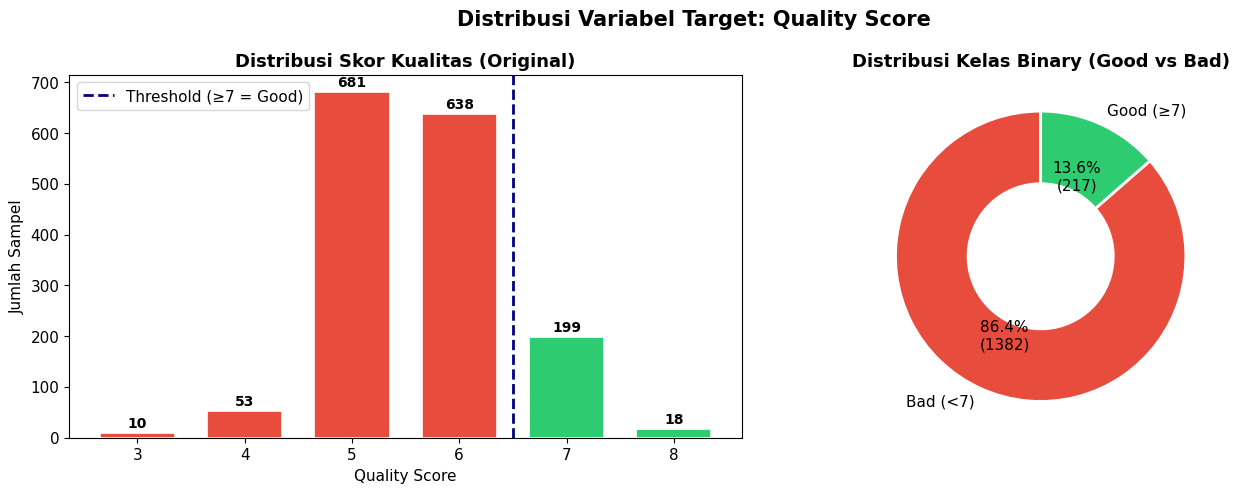


Distribusi Kelas:
quality_label
Bad (<7)     1382
Good (≥7)     217

Rasio Imbalance: 6.37:1 → Dataset tidak seimbang!


In [6]:
# ============================================================
# 4.2 Distribusi Variabel Target
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Variabel Target: Quality Score", fontsize=15, fontweight='bold')

# Plot kiri: distribusi skor asli
quality_counts = df['quality'].value_counts().sort_index()
bars = axes[0].bar(
    quality_counts.index, quality_counts.values,
    color=['#e74c3c' if q < 7 else '#2ecc71' for q in quality_counts.index],
    edgecolor='white', linewidth=1.2, width=0.7
)
axes[0].set_title('Distribusi Skor Kualitas (Original)')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].axvline(x=6.5, color='navy', linestyle='--', linewidth=2, label='Threshold (≥7 = Good)')
axes[0].legend()
for bar, val in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot kanan: distribusi binary
df_temp = df.copy()
df_temp['quality_label'] = df_temp['quality'].apply(
    lambda x: 'Good (≥7)' if x >= 7 else 'Bad (<7)'
)
label_counts = df_temp['quality_label'].value_counts()
wedge_props  = dict(width=0.5, edgecolor='white', linewidth=2)
colors       = ['#e74c3c', '#2ecc71']

axes[1].pie(
    label_counts, labels=label_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*len(df)/100)})',
    colors=colors, startangle=90, wedgeprops=wedge_props,
    textprops={'fontsize': 11}
)
axes[1].set_title('Distribusi Kelas Binary (Good vs Bad)')

plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribusi Kelas:")
print(label_counts.to_string())
imbalance = label_counts.max() / label_counts.min()
print(f"\nRasio Imbalance: {imbalance:.2f}:1 → {'Dataset tidak seimbang!' if imbalance > 2 else 'Dataset relatif seimbang'}")


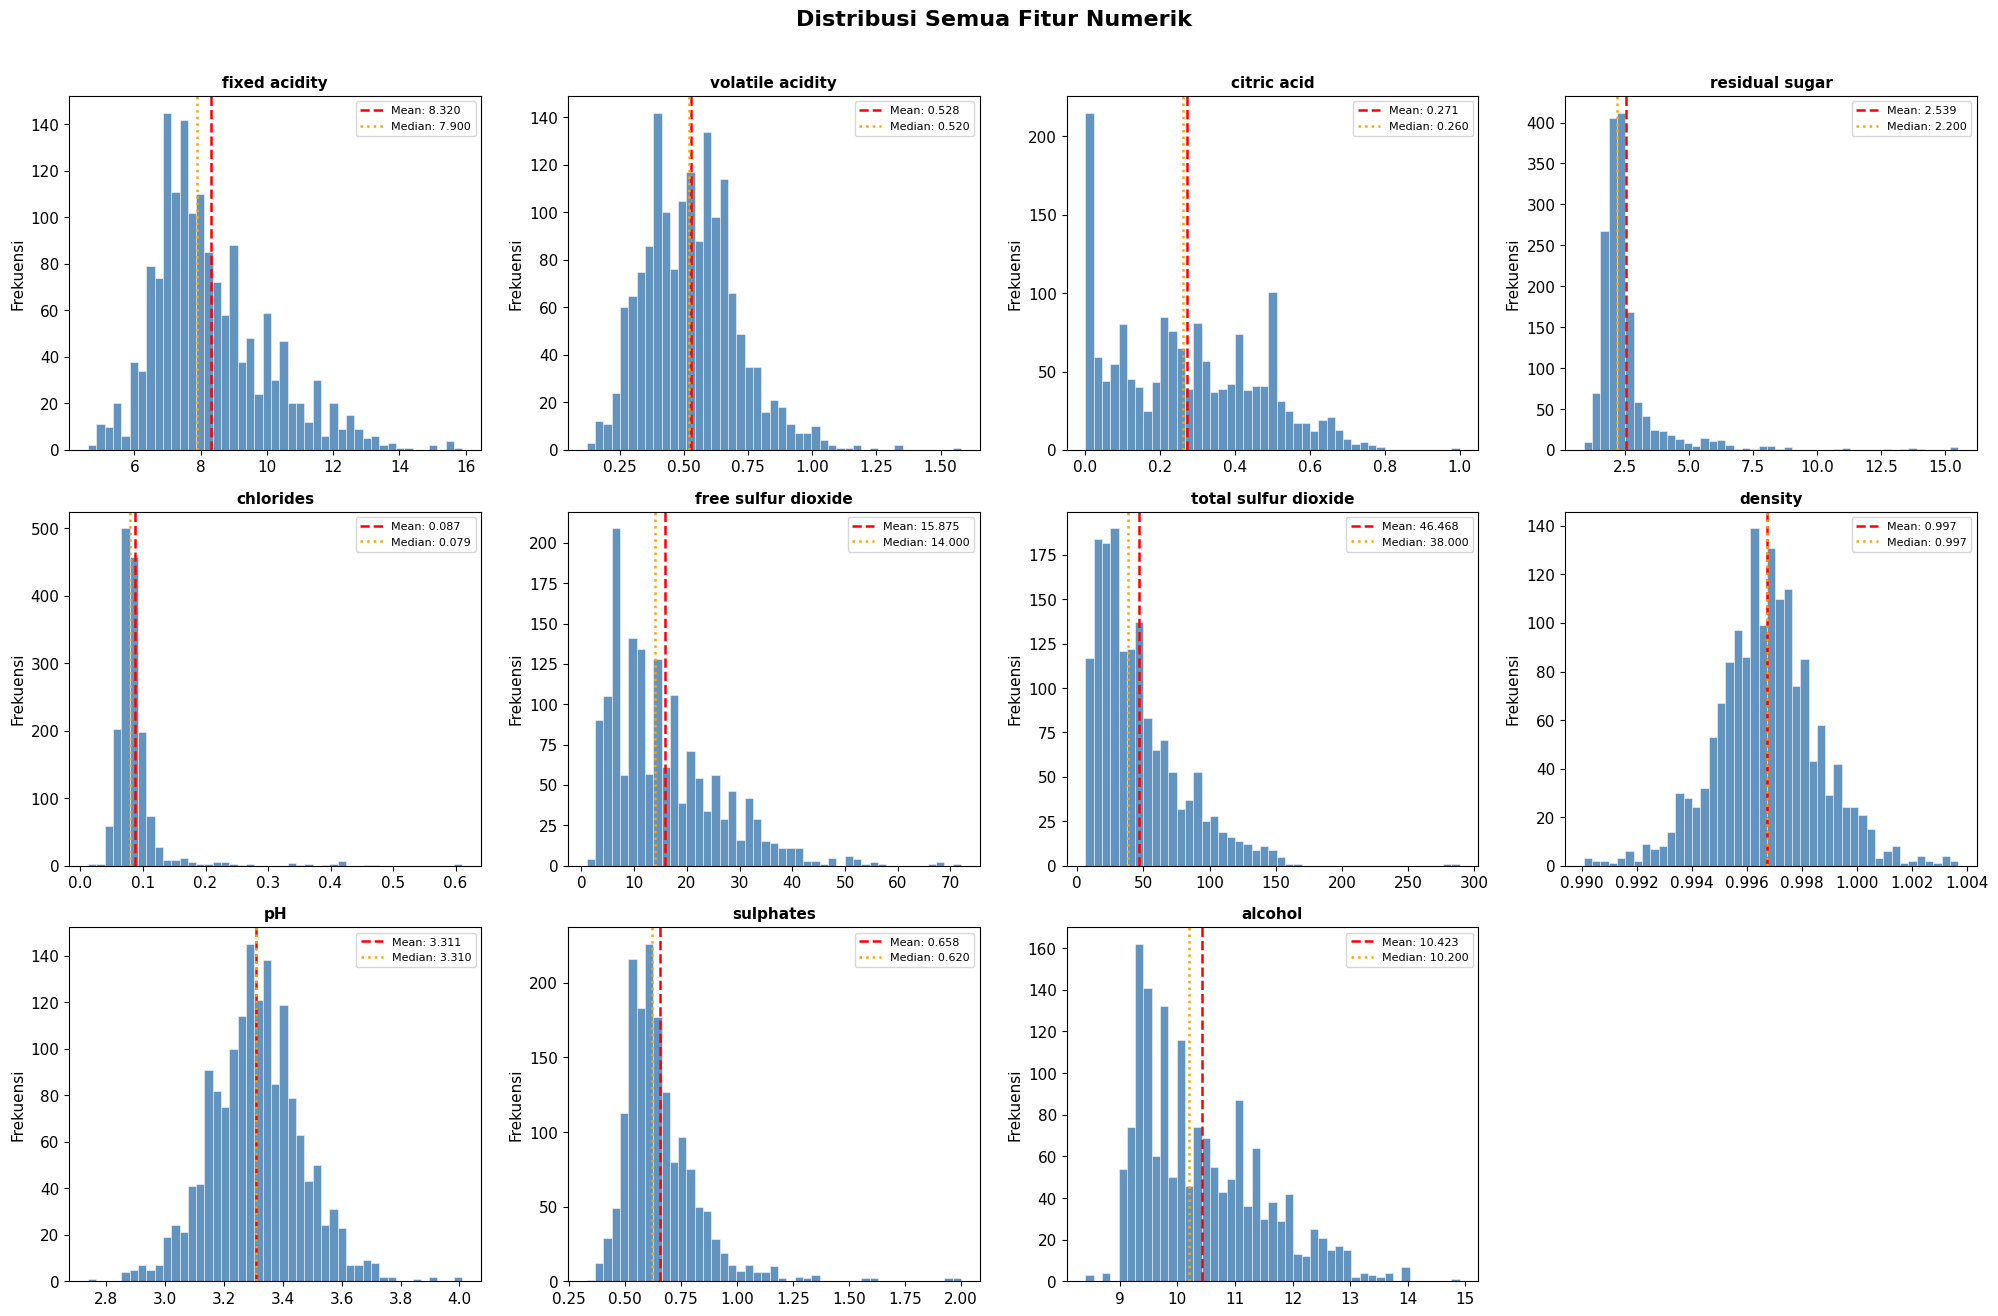

In [7]:
# ============================================================
# 4.3 Distribusi Seluruh Fitur Numerik
# ============================================================

feature_cols = [c for c in df.columns if c != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()
fig.suptitle("Distribusi Semua Fitur Numerik", fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(feature_cols):
    ax  = axes[i]
    data = df[col]
    ax.hist(data, bins=45, color='steelblue', edgecolor='white',
            linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', lw=1.8,
               label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  lw=1.8,
               label=f'Median: {data.median():.3f}')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

# Sembunyikan subplot kosong
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('eda_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


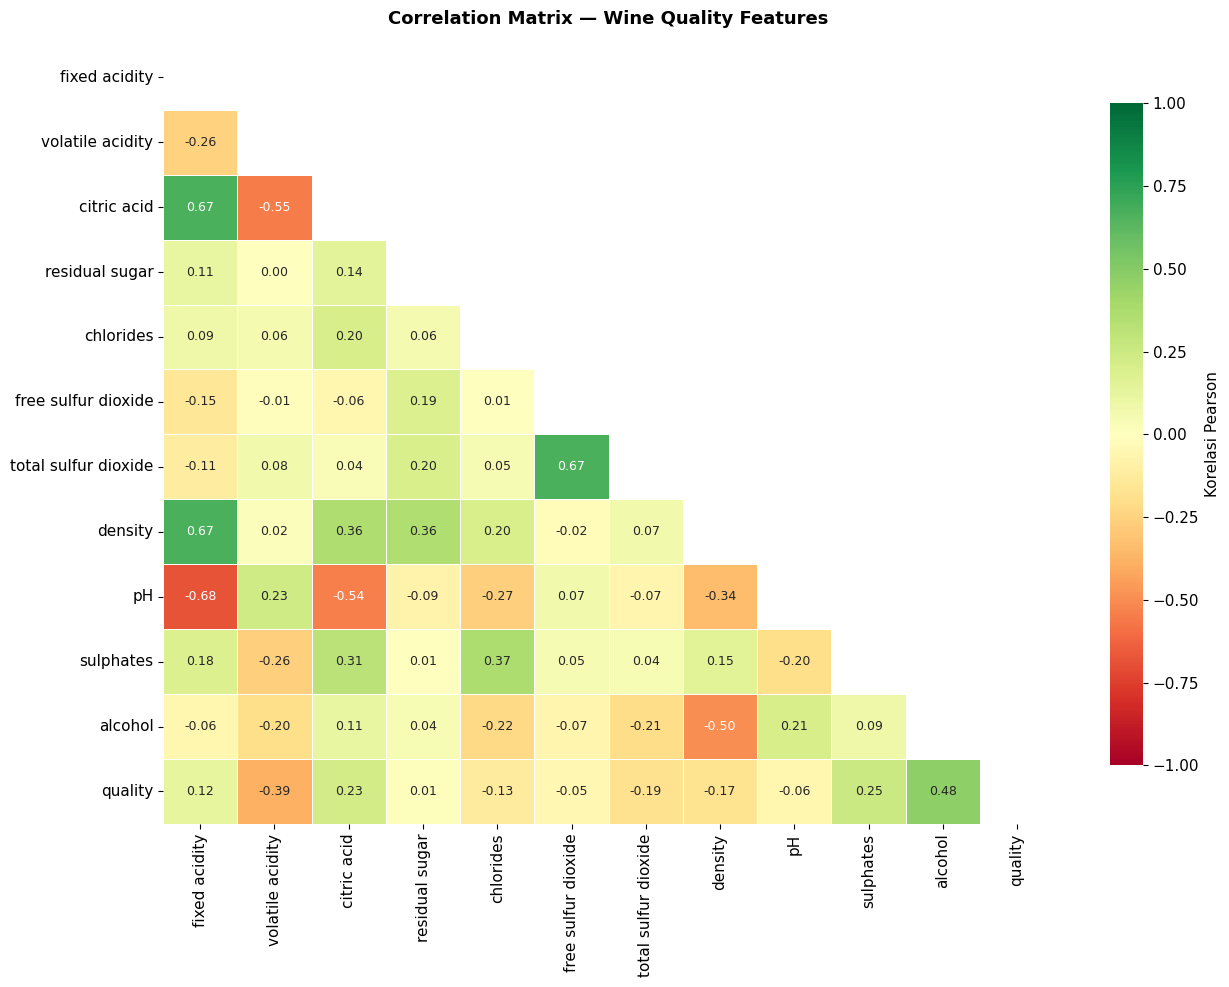

Korelasi Fitur terhadap 'quality' (diurutkan):
  alcohol                   : +0.4762  █████████
  sulphates                 : +0.2514  █████
  citric acid               : +0.2264  ████
  fixed acidity             : +0.1241  ██
  residual sugar            : +0.0137  
  free sulfur dioxide       : -0.0507  █
  pH                        : -0.0577  █
  chlorides                 : -0.1289  ██
  density                   : -0.1749  ███
  total sulfur dioxide      : -0.1851  ███
  volatile acidity          : -0.3906  ███████


In [8]:
# ============================================================
# 4.4 Correlation Matrix (Heatmap)
# ============================================================

plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 9},
    cbar_kws={'shrink': 0.85, 'label': 'Korelasi Pearson'}
)
plt.title('Correlation Matrix — Wine Quality Features', pad=15)
plt.tight_layout()
plt.savefig('eda_03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Korelasi Fitur terhadap 'quality' (diurutkan):")
corr_target = corr['quality'].drop('quality').sort_values(ascending=False)
for feat, val in corr_target.items():
    bar     = '█' * int(abs(val) * 20)
    sign    = '+' if val >= 0 else '-'
    print(f"  {feat:<26}: {sign}{abs(val):.4f}  {bar}")


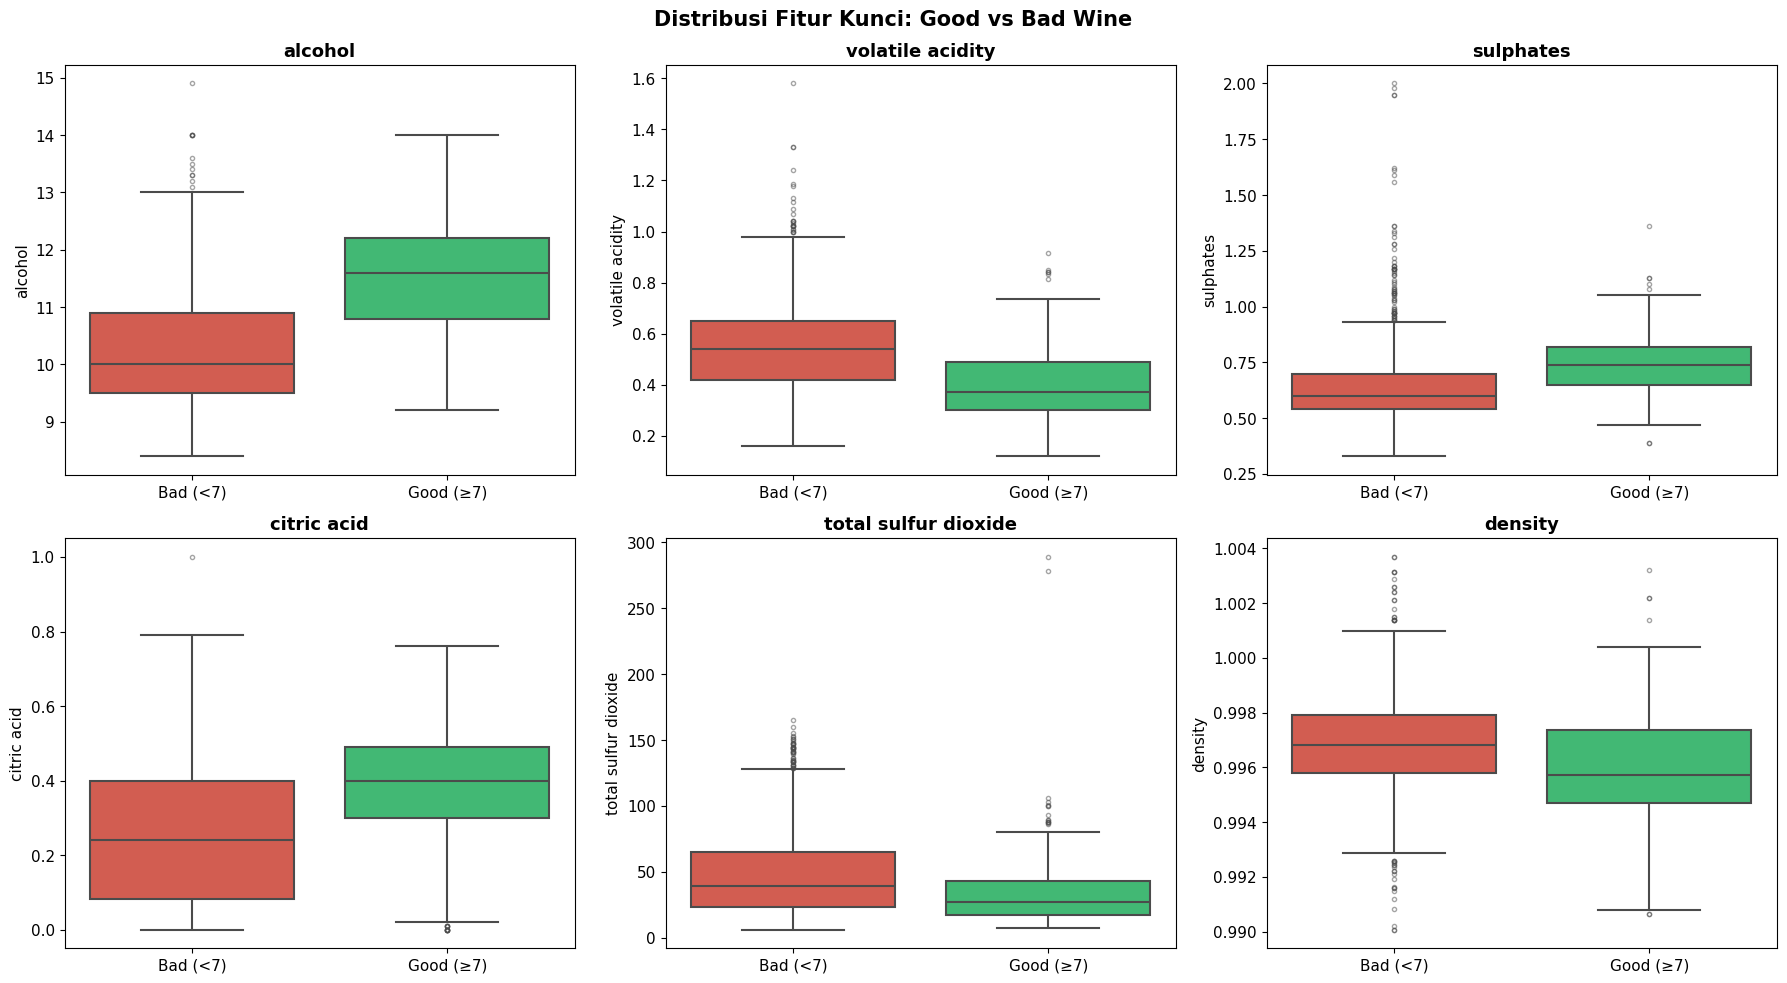

In [9]:
# ============================================================
# 4.5 Boxplot per Fitur berdasarkan Kelas (Good vs Bad)
# ============================================================

df_eda = df.copy()
df_eda['quality_label'] = df_eda['quality'].apply(
    lambda x: 'Good (≥7)' if x >= 7 else 'Bad (<7)'
)

top_feats = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid',
             'total sulfur dioxide', 'density']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.flatten()
fig.suptitle('Distribusi Fitur Kunci: Good vs Bad Wine', fontsize=15, fontweight='bold')

palette = {'Good (≥7)': '#2ecc71', 'Bad (<7)': '#e74c3c'}
for i, feat in enumerate(top_feats):
    sns.boxplot(
        data=df_eda, x='quality_label', y=feat,
        palette=palette, ax=axes[i],
        order=['Bad (<7)', 'Good (≥7)'],
        linewidth=1.5, flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('eda_04_boxplot_by_class.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ============================================================
# 4.6 Deteksi Outlier — Metode IQR
# ============================================================

print("=" * 58)
print("DETEKSI OUTLIER — METODE IQR (Q1 - 1.5×IQR, Q3 + 1.5×IQR)")
print("=" * 58)

outlier_info = {}
for col in feature_cols:
    Q1     = df[col].quantile(0.25)
    Q3     = df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = {
        'Q1':          round(Q1, 4),
        'Q3':          round(Q3, 4),
        'IQR':         round(IQR, 4),
        'Batas Bawah': round(lower, 4),
        'Batas Atas':  round(upper, 4),
        'Jumlah Outlier': int(n_out),
        'Persen (%)':  round(n_out / len(df) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_info).T
print(outlier_df[['Batas Bawah', 'Batas Atas', 'Jumlah Outlier', 'Persen (%)']].to_string())

total_out = outlier_df['Jumlah Outlier'].sum()
print(f"\nTotal nilai outlier terdeteksi : {total_out:,}")
print(f"Strategi penanganan            : IQR Capping (Winsorization)")


DETEKSI OUTLIER — METODE IQR (Q1 - 1.5×IQR, Q3 + 1.5×IQR)
                      Batas Bawah  Batas Atas  Jumlah Outlier  Persen (%)
fixed acidity              3.9500     12.3500            49.0        3.06
volatile acidity           0.0150      1.0150            19.0        1.19
citric acid               -0.4050      0.9150             1.0        0.06
residual sugar             0.8500      3.6500           155.0        9.69
chlorides                  0.0400      0.1200           112.0        7.00
free sulfur dioxide      -14.0000     42.0000            30.0        1.88
total sulfur dioxide     -38.0000    122.0000            55.0        3.44
density                    0.9922      1.0012            45.0        2.81
pH                         2.9250      3.6850            35.0        2.19
sulphates                  0.2800      1.0000            59.0        3.69
alcohol                    7.1000     13.5000            13.0        0.81

Total nilai outlier terdeteksi : 573.0
Strategi penan

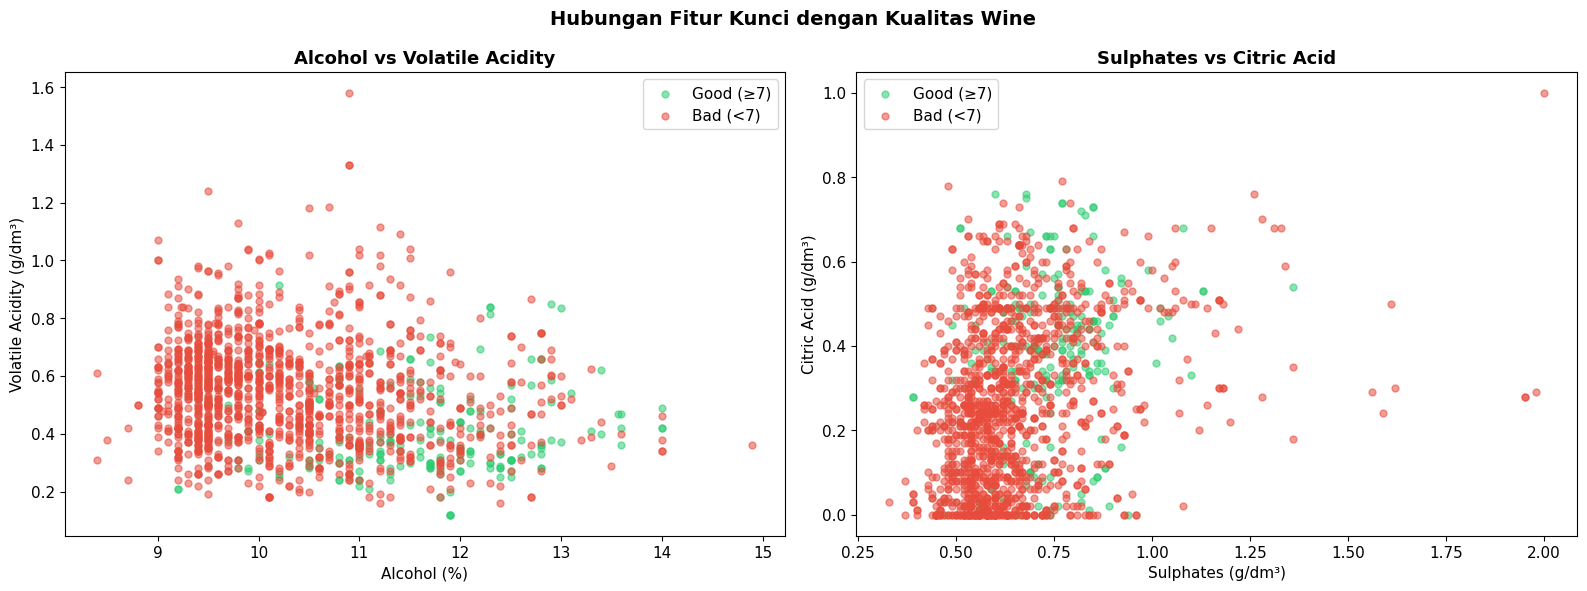


✅ EDA selesai — 5 visualisasi disimpan.


In [11]:
# ============================================================
# 4.7 Scatter Plot: Alcohol vs Volatile Acidity (colored by class)
# ============================================================

df_eda2 = df.copy()
df_eda2['quality_label'] = df_eda2['quality'].apply(
    lambda x: 'Good (≥7)' if x >= 7 else 'Bad (<7)'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Hubungan Fitur Kunci dengan Kualitas Wine", fontsize=14, fontweight='bold')

# Scatter: Alcohol vs Volatile Acidity
for label, color in [('Good (≥7)', '#2ecc71'), ('Bad (<7)', '#e74c3c')]:
    subset = df_eda2[df_eda2['quality_label'] == label]
    axes[0].scatter(
        subset['alcohol'], subset['volatile acidity'],
        label=label, color=color, alpha=0.55, s=25
    )
axes[0].set_xlabel('Alcohol (%)')
axes[0].set_ylabel('Volatile Acidity (g/dm³)')
axes[0].set_title('Alcohol vs Volatile Acidity')
axes[0].legend()

# Scatter: Sulphates vs Citric Acid
for label, color in [('Good (≥7)', '#2ecc71'), ('Bad (<7)', '#e74c3c')]:
    subset = df_eda2[df_eda2['quality_label'] == label]
    axes[1].scatter(
        subset['sulphates'], subset['citric acid'],
        label=label, color=color, alpha=0.55, s=25
    )
axes[1].set_xlabel('Sulphates (g/dm³)')
axes[1].set_ylabel('Citric Acid (g/dm³)')
axes[1].set_title('Sulphates vs Citric Acid')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_05_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ EDA selesai — 5 visualisasi disimpan.")


# **5. Data Preprocessing**

Pada tahap ini, kita membersihkan dan mempersiapkan data agar siap dilatih oleh model machine learning. Tahapan yang dilakukan:

1. **Menghapus Data Duplikat** — menghilangkan baris identik untuk mencegah model overfitting terhadap sampel yang berulang
2. **Encoding Target Variable** — mengubah skor kualitas numerik menjadi label binary (Good/Bad)
3. **Deteksi dan Penanganan Outlier** — IQR Capping (Winsorization) mempertahankan semua data point sambil membatasi nilai ekstrem
4. **Normalisasi / Standarisasi Fitur** — StandardScaler memastikan semua fitur berada pada skala yang sama (mean ≈ 0, std ≈ 1)
5. **Pembagian Dataset** — Train-Test Split stratified 80:20 menjaga distribusi kelas


In [12]:
# ============================================================
# 5.1 Hapus Baris Duplikat
# ============================================================

df_clean = df.copy()

before_dup = len(df_clean)
df_clean   = df_clean.drop_duplicates().reset_index(drop=True)
after_dup  = len(df_clean)
removed    = before_dup - after_dup

print("=" * 45)
print("LANGKAH 1: Menghapus Baris Duplikat")
print("=" * 45)
print(f"  Sebelum : {before_dup:,} baris")
print(f"  Sesudah : {after_dup:,} baris")
print(f"  Dihapus : {removed:,} baris ({removed/before_dup*100:.1f}%)")
print(f"  Status  : ✅ Selesai")


LANGKAH 1: Menghapus Baris Duplikat
  Sebelum : 1,599 baris
  Sesudah : 1,359 baris
  Dihapus : 240 baris (15.0%)
  Status  : ✅ Selesai


In [13]:
# ============================================================
# 5.2 Encoding Target Variable (Binary Classification)
# ============================================================

df_clean['quality_binary'] = (df_clean['quality'] >= 7).astype(int)
df_clean = df_clean.drop(columns=['quality'])

print("=" * 45)
print("LANGKAH 2: Encoding Target Variable")
print("=" * 45)
print(f"  Aturan  : quality >= 7 → 1 (Good) | quality < 7 → 0 (Bad)")
vc = df_clean['quality_binary'].value_counts()
print(f"  Bad  (0): {vc.get(0,0):,} sampel  ({vc.get(0,0)/len(df_clean)*100:.1f}%)")
print(f"  Good (1): {vc.get(1,0):,} sampel  ({vc.get(1,0)/len(df_clean)*100:.1f}%)")
print(f"  Shape   : {df_clean.shape}")
print(f"  Status  : ✅ Selesai")


LANGKAH 2: Encoding Target Variable
  Aturan  : quality >= 7 → 1 (Good) | quality < 7 → 0 (Bad)
  Bad  (0): 1,175 sampel  (86.5%)
  Good (1): 184 sampel  (13.5%)
  Shape   : (1359, 12)
  Status  : ✅ Selesai


In [14]:
# ============================================================
# 5.3 Penanganan Outlier — IQR Capping (Winsorization)
# ============================================================

feature_cols_clean = [c for c in df_clean.columns if c != 'quality_binary']
df_capped          = df_clean.copy()
total_capped       = 0

print("=" * 55)
print("LANGKAH 3: Penanganan Outlier — IQR Capping")
print("=" * 55)

for col in feature_cols_clean:
    Q1  = df_capped[col].quantile(0.25)
    Q3  = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR

    n_before        = ((df_capped[col] < lo) | (df_capped[col] > hi)).sum()
    df_capped[col]  = df_capped[col].clip(lower=lo, upper=hi)
    total_capped   += n_before

    if n_before > 0:
        print(f"  {col:<26}: {n_before:>3} nilai dikap  [batas: {lo:.4f}, {hi:.4f}]")

print(f"\n  Total nilai yang di-cap : {total_capped:,}")
print(f"  Status                  : ✅ Selesai")


LANGKAH 3: Penanganan Outlier — IQR Capping
  fixed acidity             :  41 nilai dikap  [batas: 3.9500, 12.3500]
  volatile acidity          :  19 nilai dikap  [batas: 0.0150, 1.0150]
  citric acid               :   1 nilai dikap  [batas: -0.4200, 0.9400]
  residual sugar            : 126 nilai dikap  [batas: 0.8500, 3.6500]
  chlorides                 :  87 nilai dikap  [batas: 0.0385, 0.1225]
  free sulfur dioxide       :  26 nilai dikap  [batas: -14.0000, 42.0000]
  total sulfur dioxide      :  45 nilai dikap  [batas: -39.5000, 124.5000]
  density                   :  35 nilai dikap  [batas: 0.9923, 1.0011]
  pH                        :  28 nilai dikap  [batas: 2.9250, 3.6850]
  sulphates                 :  55 nilai dikap  [batas: 0.2800, 1.0000]
  alcohol                   :  12 nilai dikap  [batas: 7.1000, 13.5000]

  Total nilai yang di-cap : 475
  Status                  : ✅ Selesai


In [15]:
# ============================================================
# 5.4 Standarisasi Fitur — StandardScaler
# ============================================================

X = df_capped.drop(columns=['quality_binary'])
y = df_capped['quality_binary']

scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("=" * 50)
print("LANGKAH 4: Standarisasi Fitur — StandardScaler")
print("=" * 50)
print(f"  Fitur yang diskalakan : {list(X.columns)}")
print(f"\n  Statistik setelah scaling (mean ≈ 0, std ≈ 1):")
stats = X_scaled.agg(['mean', 'std']).round(4)
print(stats.to_string())
print(f"\n  Status : ✅ Selesai")


LANGKAH 4: Standarisasi Fitur — StandardScaler
  Fitur yang diskalakan : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

  Statistik setelah scaling (mean ≈ 0, std ≈ 1):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density      pH  sulphates  alcohol
mean        -0.0000           -0.0000       0.0000         -0.0000     0.0000              -0.0000                0.0000  -0.0000  0.0000    -0.0000  -0.0000
std          1.0004            1.0004       1.0004          1.0004     1.0004               1.0004                1.0004   1.0004  1.0004     1.0004   1.0004

  Status : ✅ Selesai


In [16]:
# ============================================================
# 5.5 Train-Test Split (Stratified, 80:20)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("LANGKAH 5: Train-Test Split")
print("=" * 50)
print(f"  Total data        : {len(X_scaled):,}")
print(f"  Training set      : {len(X_train):,} ({len(X_train)/len(X_scaled)*100:.0f}%)")
print(f"  Testing set       : {len(X_test):,}  ({len(X_test)/len(X_scaled)*100:.0f}%)")
print(f"  Stratified        : Ya (distribusi kelas terjaga)")

print(f"\n  Distribusi kelas — Train:")
vc_train = y_train.value_counts()
print(f"    Bad  (0): {vc_train.get(0,0):,}  ({vc_train.get(0,0)/len(y_train)*100:.1f}%)")
print(f"    Good (1): {vc_train.get(1,0):,}   ({vc_train.get(1,0)/len(y_train)*100:.1f}%)")
print(f"\n  Distribusi kelas — Test:")
vc_test  = y_test.value_counts()
print(f"    Bad  (0): {vc_test.get(0,0):,}   ({vc_test.get(0,0)/len(y_test)*100:.1f}%)")
print(f"    Good (1): {vc_test.get(1,0):,}    ({vc_test.get(1,0)/len(y_test)*100:.1f}%)")
print(f"\n  Status : ✅ Selesai")


LANGKAH 5: Train-Test Split
  Total data        : 1,359
  Training set      : 1,087 (80%)
  Testing set       : 272  (20%)
  Stratified        : Ya (distribusi kelas terjaga)

  Distribusi kelas — Train:
    Bad  (0): 940  (86.5%)
    Good (1): 147   (13.5%)

  Distribusi kelas — Test:
    Bad  (0): 235   (86.4%)
    Good (1): 37    (13.6%)

  Status : ✅ Selesai


In [17]:
# ============================================================
# 5.6 Sanity Check — Baseline Model
# ============================================================

baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train, y_train)

y_pred_b  = baseline_rf.predict(X_test)
y_proba_b = baseline_rf.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred_b)
f1      = f1_score(y_test, y_pred_b)
roc     = roc_auc_score(y_test, y_proba_b)

print("=" * 50)
print("SANITY CHECK — Random Forest (default params)")
print("=" * 50)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")
print()
print(classification_report(y_test, y_pred_b, target_names=['Bad (0)', 'Good (1)']))


SANITY CHECK — Random Forest (default params)
  Accuracy : 0.8860  (88.60%)
  F1-Score : 0.4561
  ROC-AUC  : 0.8621

              precision    recall  f1-score   support

     Bad (0)       0.90      0.97      0.94       235
    Good (1)       0.65      0.35      0.46        37

    accuracy                           0.89       272
   macro avg       0.78      0.66      0.70       272
weighted avg       0.87      0.89      0.87       272



In [18]:
# ============================================================
# 5.7 Simpan Dataset Hasil Preprocessing
# ============================================================

os.makedirs("winequality_preprocessing", exist_ok=True)

# Full preprocessed dataset
df_full = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)
df_full.to_csv("winequality_preprocessing/winequality_preprocessed.csv", index=False)

# Train set
df_train_out = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1
)
df_train_out.to_csv("winequality_preprocessing/train.csv", index=False)

# Test set
df_test_out = pd.concat(
    [X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1
)
df_test_out.to_csv("winequality_preprocessing/test.csv", index=False)

# Scaler
with open("winequality_preprocessing/scaler.pkl", "wb") as fh:
    pickle.dump(scaler, fh)

print("=" * 55)
print("PREPROCESSING SELESAI — Artefak Tersimpan")
print("=" * 55)
print(f"  winequality_preprocessing/winequality_preprocessed.csv  ← {len(df_full):,} baris")
print(f"  winequality_preprocessing/train.csv                     ← {len(df_train_out):,} baris")
print(f"  winequality_preprocessing/test.csv                      ← {len(df_test_out):,} baris")
print(f"  winequality_preprocessing/scaler.pkl                    ← StandardScaler fitted")
print()
print("  Kolom fitur  :", list(X_scaled.columns))
print("  Target kolom : quality_binary")
print()
print("Dataset siap untuk tahap pelatihan model (Kriteria 2).")


PREPROCESSING SELESAI — Artefak Tersimpan
  winequality_preprocessing/winequality_preprocessed.csv  ← 1,359 baris
  winequality_preprocessing/train.csv                     ← 1,087 baris
  winequality_preprocessing/test.csv                      ← 272 baris
  winequality_preprocessing/scaler.pkl                    ← StandardScaler fitted

  Kolom fitur  : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
  Target kolom : quality_binary

Dataset siap untuk tahap pelatihan model (Kriteria 2).
